# Ноутбук №1: детекция транспортных средств и номерных знаков

**Задачи ноутбука:**
1. Детекция транспортных средств с помощью YOLO26n, предобученной на COCO.
2. Сравнение предобученных архитектур: YOLO26n vs YOLOv8n — скорость и COCO-бенчмарки.
3. Дообучение основной модели YOLO26n на датасете номерных знаков; сравнение с baseline YOLOv8n и автовыбор лучшей модели.
4. Анализ детектора: кривые обучения, IoU-распределение, примеры False Negative, влияние порога conf.
5. OCR номерных знаков с помощью EasyOCR: предобработка (апскейл, бинаризация), позиционная коррекция.
6. Оценка OCR на синтетических номерах и реальных данных (NOMEROFF-NET RU, 200 изображений).
7. Визуализация ошибок OCR: примеры верных и ошибочных распознаваний, анализ замен символов.

**Основные результаты:**
- `yolo26n_plates.pt` — дообученный детектор номерных знаков (основная модель) → Google Drive
- `detector_choice.json` — автоматический выбор победителя YOLO26n vs YOLOv8n → Google Drive

## 1. Настройка окружения

In [1]:
%%capture
!pip install -q ultralytics easyocr opencv-python-headless Pillow matplotlib numpy pandas tensorboard

In [2]:
import torch
from google.colab.patches import cv2_imshow
import re
import json
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings('ignore')


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WORK_DIR = Path('diploma_01_detection')
OUTPUT_DIR = WORK_DIR / 'output'
DATA_DIR = WORK_DIR / 'data'
for d in [OUTPUT_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')

Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_MODELS = Path('/content/drive/MyDrive/diploma/models')
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
PLATES_MODEL_PATH = DRIVE_MODELS / 'yolo26n_plates.pt'          # основная модель (YOLO26n)
YOLOV8_PLATES_MODEL_PATH = DRIVE_MODELS / 'yolov8n_plates.pt'   # baseline для сравнения
print(f'Модели логируются по пути: {DRIVE_MODELS}')

Mounted at /content/drive
Модели логируются по пути: /content/drive/MyDrive/diploma/models


## 2. Детекция транспортных средств — YOLO26n, предобученная на COCO

| ID класса COCO | Класс по COCO | Описание |
|---:|---|---|
| 2 | car | автомобиль |
| 3 | motorcycle | мотоцикл |
| 5 | bus | автобус |
| 7 | truck | грузовик |

In [4]:
from ultralytics import YOLO

vehicle_model = YOLO('yolo26n.pt')
VEHICLE_CLASSES = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Загружено: /content/drive/MyDrive/diploma/test_images/rr.jpg  |  размер: 1200x799


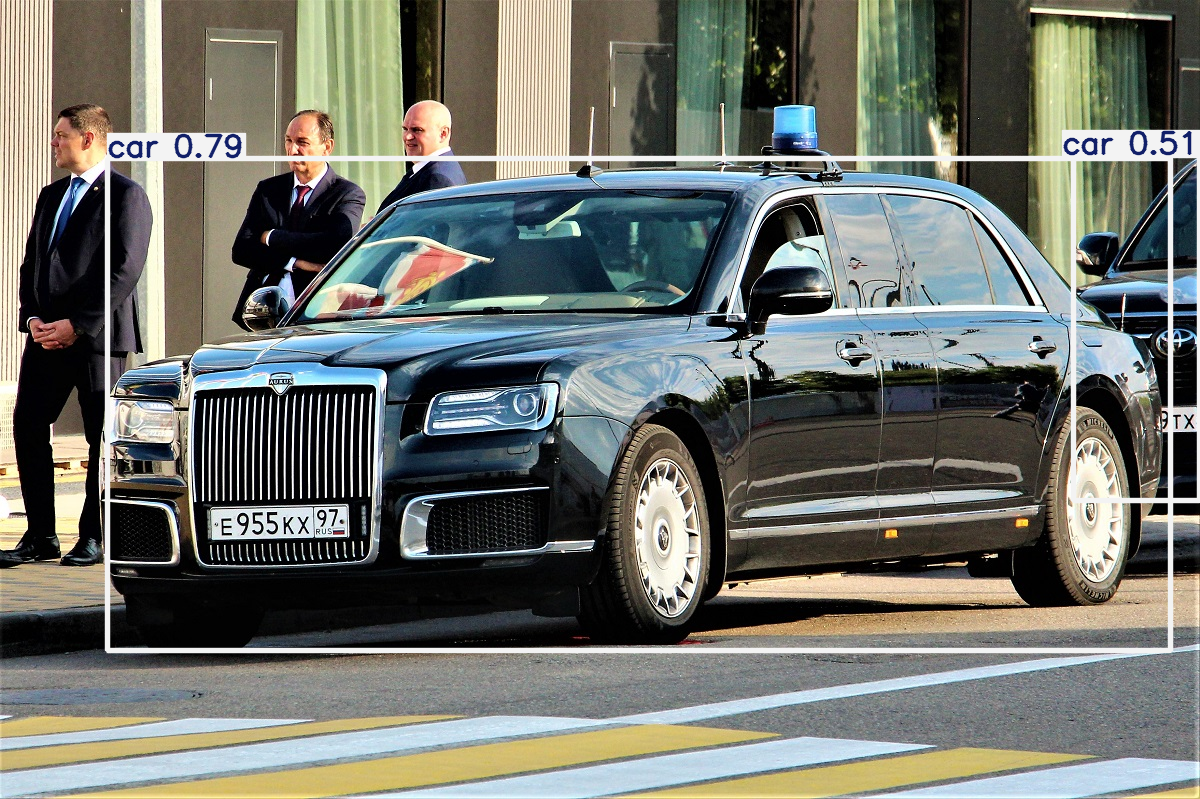

Обнаружено: 2 объект(ов)
  car           conf=0.791
  car           conf=0.512


In [5]:
img_path = '/content/drive/MyDrive/diploma/test_images/rr.jpg'
img = cv2.imread(img_path)
print(f'Загружено: {img_path}  |  размер: {img.shape[1]}x{img.shape[0]}')

res = vehicle_model(img, conf=0.4, classes=list(VEHICLE_CLASSES.keys()), verbose=False)[0]
annotated = res.plot()
cv2_imshow(annotated)
cv2.imwrite(str(OUTPUT_DIR / 'vehicle_detection_demo.jpg'), annotated)

print(f'Обнаружено: {len(res.boxes)} объект(ов)')
for b in res.boxes:
    cid = int(b.cls.item())
    print(f'  {VEHICLE_CLASSES.get(cid, "?"):12s}  conf={b.conf.item():.3f}')

COCO Benchmark (официальные значения из документации Ultralytics)
 Модель  mAP50-95 (COCO)  Params, M  GFLOPs
YOLOv8n             37.3        3.2     8.7
YOLO26n             40.9        2.4     5.4
YOLOv8n: 2 объектов | 9.7 мс/кадр
YOLO26n: 2 объектов | 12.5 мс/кадр

Скорость инференса (предобученные)
 Модель  Объектов  Инференс, мс
YOLOv8n         2           9.7
YOLO26n         2          12.5


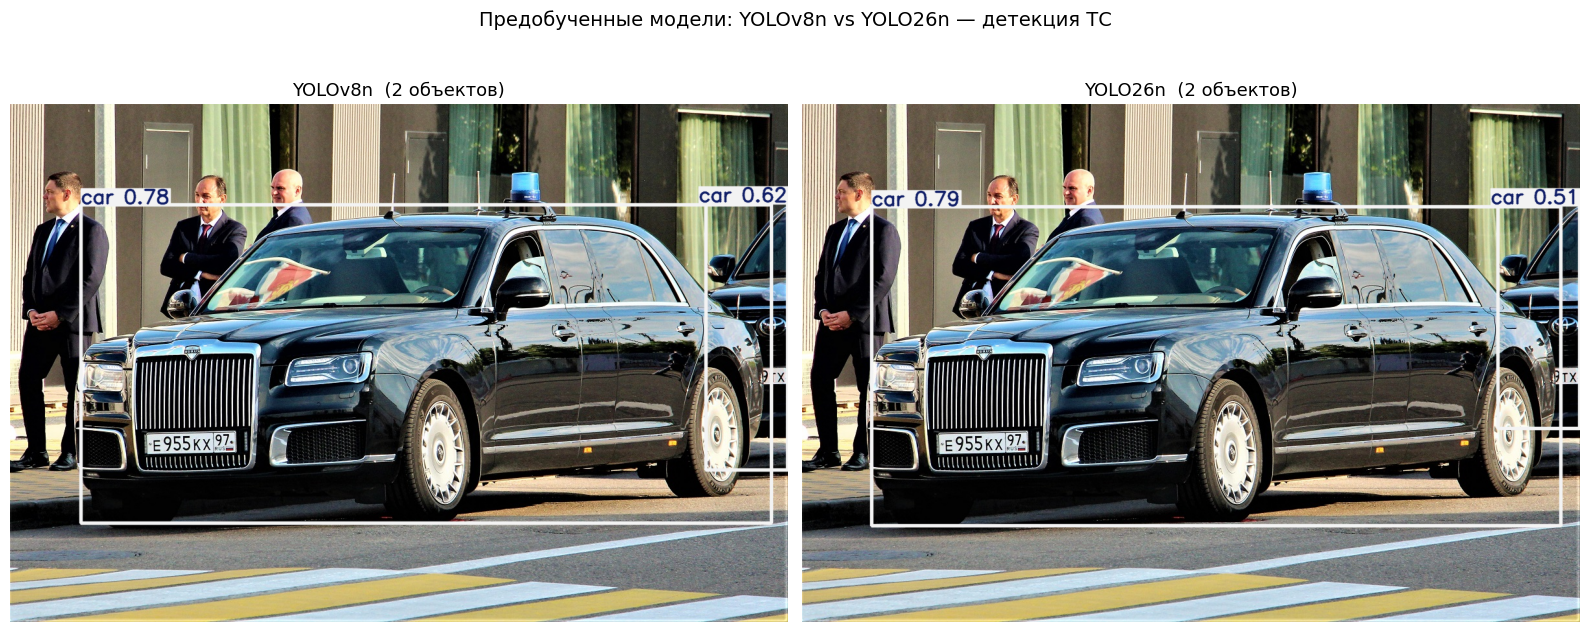

In [6]:
import time
import pandas as pd
from ultralytics import YOLO

_img_path = '/content/drive/MyDrive/diploma/test_images/rr.jpg'
_img_cmp = cv2.imread(_img_path)

_PRETRAINED = {
    'YOLOv8n': YOLO('yolov8n.pt'),
    'YOLO26n': YOLO('yolo26n.pt'),
}

_coco_bench = pd.DataFrame([
    {'Модель': 'YOLOv8n', 'mAP50-95 (COCO)': 37.3, 'Params, M': 3.2, 'GFLOPs': 8.7},
    {'Модель': 'YOLO26n', 'mAP50-95 (COCO)': 40.9, 'Params, M': 2.4, 'GFLOPs': 5.4},
])
print('COCO Benchmark (официальные значения из документации Ultralytics)')
print(_coco_bench.to_string(index=False))

N_RUNS = 20
_speed_rows = []
for _name, _m in _PRETRAINED.items():
    _m(_img_cmp, conf=0.4, classes=list(VEHICLE_CLASSES.keys()), verbose=False)  # warm-up
    _t0 = time.perf_counter()
    for _ in range(N_RUNS):
        _r = _m(_img_cmp, conf=0.4, classes=list(VEHICLE_CLASSES.keys()), verbose=False)[0]
    _ms = (time.perf_counter() - _t0) / N_RUNS * 1000
    _speed_rows.append({'Модель': _name, 'Объектов': len(_r.boxes), 'Инференс, мс': round(_ms, 1)})
    print(f'{_name}: {len(_r.boxes)} объектов | {_ms:.1f} мс/кадр')

_df_speed = pd.DataFrame(_speed_rows)
print('\nСкорость инференса (предобученные)')
print(_df_speed.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (_name, _m) in zip(axes, _PRETRAINED.items()):
    _r = _m(_img_cmp, conf=0.4, classes=list(VEHICLE_CLASSES.keys()), verbose=False)[0]
    ax.imshow(cv2.cvtColor(_r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f'{_name}  ({len(_r.boxes)} объектов)', fontsize=13)
    ax.axis('off')
plt.suptitle('Предобученные модели: YOLOv8n vs YOLO26n — детекция ТС', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'pretrained_comparison.jpg'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Детекция номерных знаков — Fine-tuning YOLO26n

In [7]:
import random
import shutil
from pathlib import Path

PLATES_DIR = DATA_DIR / 'plates'
RAW_DIR = PLATES_DIR / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

_train_imgs = list((RAW_DIR / 'train' / 'images').glob('*.jpg')) \
    if (RAW_DIR / 'train' / 'images').exists() else []
if not _train_imgs:
    !pip install -q kaggle
    !kaggle datasets download -d tomilovivan/russian-license-plates -p {str(RAW_DIR)} --unzip
    print('Датасет скачан.')
else:
    print(f'Датасет уже скачан: {len(_train_imgs)} изображений.')

if (RAW_DIR / 'valid').exists() and not (RAW_DIR / 'test').exists():
    (RAW_DIR / 'valid').rename(RAW_DIR / 'test')

_cur_test = (
    list((RAW_DIR / 'test' / 'images').glob('*.jpg'))
    + list((RAW_DIR / 'test' / 'images').glob('*.png'))
) if (RAW_DIR / 'test' / 'images').exists() else []
_all_tr = sorted(
    list((RAW_DIR / 'train' / 'images').glob('*.jpg'))
    + list((RAW_DIR / 'train' / 'images').glob('*.png'))
)
random.seed(42)
_n_move = max(0, int(len(_all_tr) * 0.2) - len(_cur_test))
_to_move = random.sample(_all_tr, _n_move)
(RAW_DIR / 'test' / 'images').mkdir(parents=True, exist_ok=True)
(RAW_DIR / 'test' / 'labels').mkdir(parents=True, exist_ok=True)
for _img_p in _to_move:
    _lbl_p = RAW_DIR / 'train' / 'labels' / (_img_p.stem + '.txt')
    _img_p.rename(RAW_DIR / 'test' / 'images' / _img_p.name)
    if _lbl_p.exists():
        _lbl_p.rename(RAW_DIR / 'test' / 'labels' / _lbl_p.name)
print(f'Resplit: {_n_move} изображений перемещено из train → test '
      f'(итого test: {len(_cur_test) + _n_move})')

Dataset URL: https://www.kaggle.com/datasets/tomilovivan/russian-license-plates
License(s): unknown
100% 102M/102M [00:01<00:00, 73.7MB/s] 

Датасет скачан.
Resplit: 92 изображений перемещено из train → test (итого test: 126)


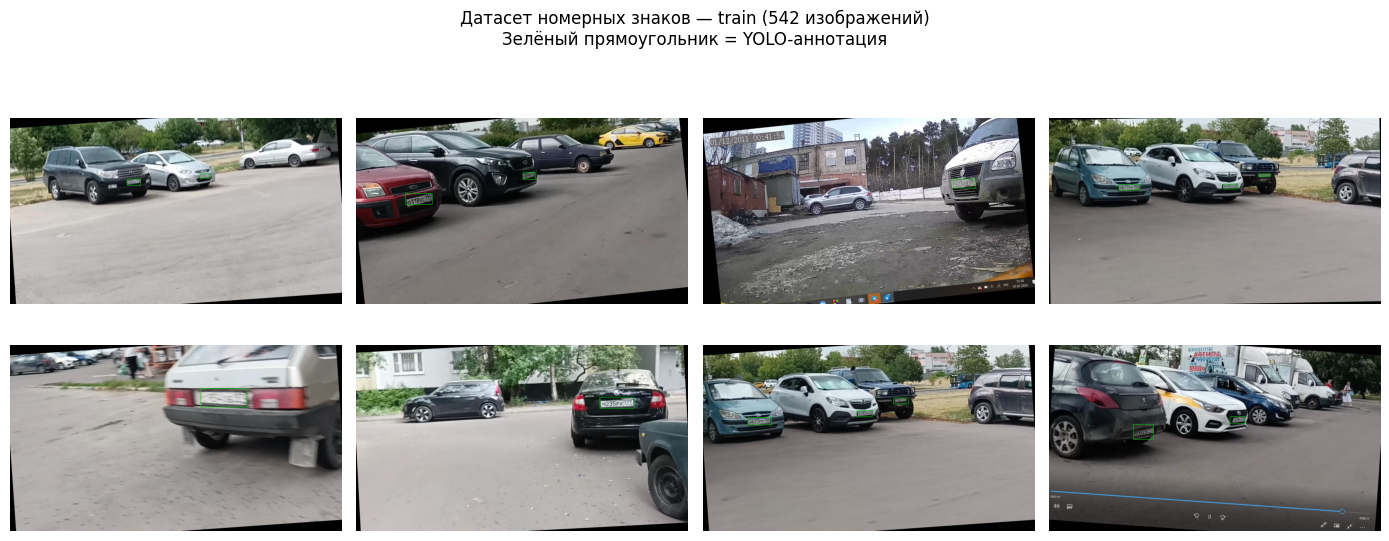

In [8]:
import random as _rnd_pl

_pl_imgs = sorted(
    list((RAW_DIR / 'train' / 'images').glob('*.jpg'))
    + list((RAW_DIR / 'train' / 'images').glob('*.png'))
)
_rnd_pl.seed(0)
_pl_show = _rnd_pl.sample(_pl_imgs, min(8, len(_pl_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, _img_p in zip(axes.flat, _pl_show):
    _bgr = cv2.imread(str(_img_p))
    _h, _w = _bgr.shape[:2]
    _lbl_p = RAW_DIR / 'train' / 'labels' / (_img_p.stem + '.txt')
    if _lbl_p.exists():
        for _line in _lbl_p.read_text().strip().splitlines():
            _parts = _line.split()
            if len(_parts) < 5:
                continue
            _cx, _cy, _bw, _bh = (float(_parts[1]), float(_parts[2]),
                                   float(_parts[3]), float(_parts[4]))
            _x1 = int((_cx - _bw / 2) * _w)
            _y1 = int((_cy - _bh / 2) * _h)
            _x2 = int((_cx + _bw / 2) * _w)
            _y2 = int((_cy + _bh / 2) * _h)
            cv2.rectangle(_bgr, (_x1, _y1), (_x2, _y2), (0, 200, 0), 2)
    ax.imshow(cv2.cvtColor(_bgr, cv2.COLOR_BGR2RGB))
    ax.axis('off')

plt.suptitle(
    f'Датасет номерных знаков — train ({len(_pl_imgs)} изображений)\n'
    f'Зелёный прямоугольник = YOLO-аннотация',
    fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'dataset_plates_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

In [9]:
train_imgs = sorted(
    list((RAW_DIR / 'train' / 'images').rglob('*.jpg'))
    + list((RAW_DIR / 'train' / 'images').rglob('*.png'))
)
test_imgs = sorted(
    list((RAW_DIR / 'test' / 'images').rglob('*.jpg'))
    + list((RAW_DIR / 'test' / 'images').rglob('*.png'))
)
train_lbls = sorted((RAW_DIR / 'train' / 'labels').rglob('*.txt'))
test_lbls = sorted((RAW_DIR / 'test' / 'labels').rglob('*.txt'))

print(f'Train: {len(train_imgs)} изображений, {len(train_lbls)} меток')
print(f'Test:  {len(test_imgs)} изображений, {len(test_lbls)} меток')

Train: 542 изображений, 542 меток
Test:  126 изображений, 126 меток


In [10]:
n_train = len(train_imgs)
n_test = len(test_imgs)
print(f'train: {n_train} | test: {n_test}')

train: 542 | test: 126


In [11]:
DATA_YAML = str(PLATES_DIR / 'dataset.yaml')
yaml_content = f"""path: {RAW_DIR.resolve()}
train: train/images
val:   test/images
nc: 1
names: ['license_plate']
"""
Path(DATA_YAML).write_text(yaml_content)
print(f'dataset.yaml -> {DATA_YAML}')

plate_model = YOLO('yolo26n.pt')
plate_model.train(
    data=DATA_YAML,
    epochs=50,
    batch=16,
    imgsz=640,
    device=DEVICE,
    project=str(WORK_DIR / 'runs'),
    name='plates_yolo26n',
    patience=15,
    val=True,
)

best = Path(plate_model.trainer.best)
shutil.copy(best, PLATES_MODEL_PATH)
print(f'Веса -> {PLATES_MODEL_PATH}')

dataset.yaml -> diploma_01_detection/data/plates/dataset.yaml
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=diploma_01_detection/data/plates/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plates_yolo26n, nbs=64, nms

results.csv: 50 эпох, столбцы: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


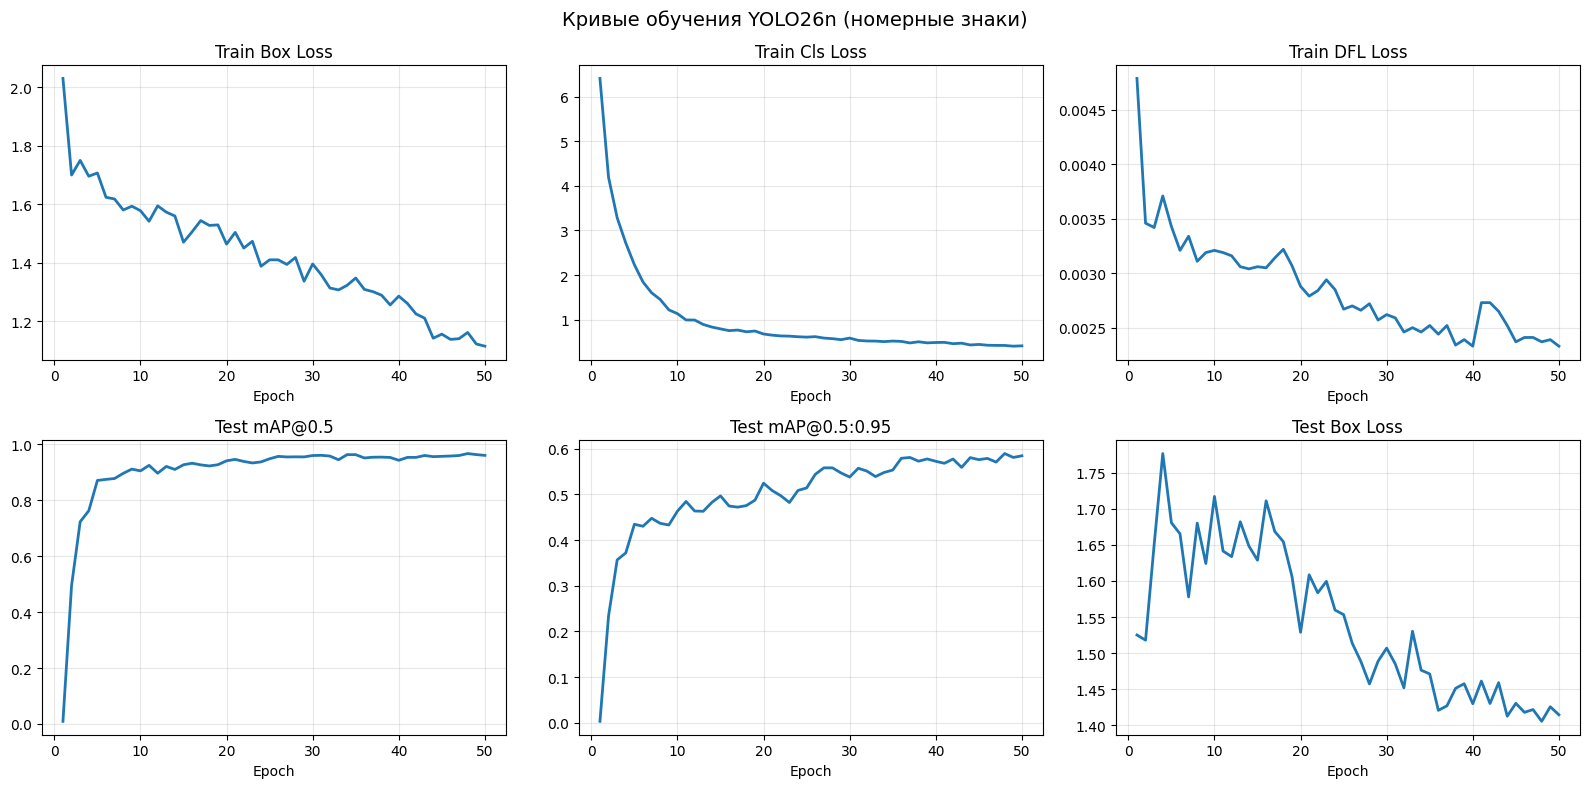

График -> diploma_01_detection/output/training_curves.png


In [12]:
import pandas as pd

_csv_path = Path(plate_model.trainer.save_dir) / 'results.csv'
_df = pd.read_csv(_csv_path)
_df.columns = _df.columns.str.strip()
print(f'results.csv: {len(_df)} эпох, столбцы: {list(_df.columns)}')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Кривые обучения YOLO26n (номерные знаки)', fontsize=14)

_plots = [
    ('train/box_loss', 'Train Box Loss', axes[0, 0]),
    ('train/cls_loss', 'Train Cls Loss', axes[0, 1]),
    ('train/dfl_loss', 'Train DFL Loss', axes[0, 2]),
    ('metrics/mAP50(B)', 'Test mAP@0.5', axes[1, 0]),
    ('metrics/mAP50-95(B)', 'Test mAP@0.5:0.95', axes[1, 1]),
    ('val/box_loss', 'Test Box Loss', axes[1, 2]),
]

for _col, _label, _ax in _plots:
    if _col in _df.columns:
        _ax.plot(_df['epoch'], _df[_col], linewidth=2)
        _ax.set_title(_label)
        _ax.set_xlabel('Epoch')
        _ax.grid(True, alpha=0.3)
    else:
        _ax.set_visible(False)

plt.tight_layout()
_out = OUTPUT_DIR / 'training_curves.png'
plt.savefig(str(_out), dpi=130, bbox_inches='tight')
plt.show()
print(f'График -> {_out}')

Папка с результатами обучения: /content/runs/detect/diploma_01_detection/runs/plates_yolo26n


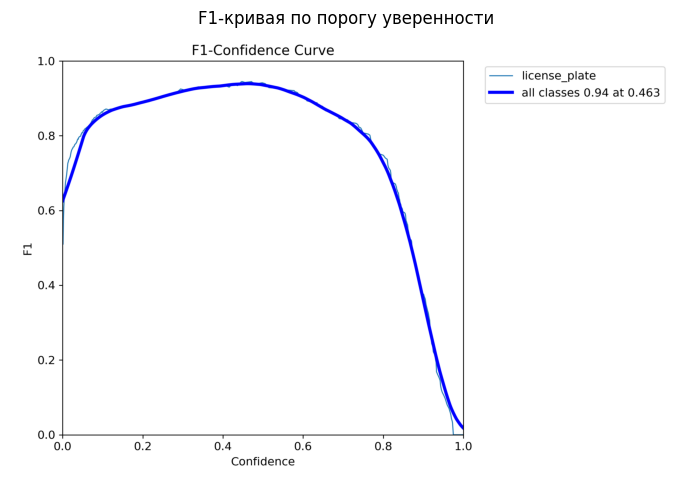

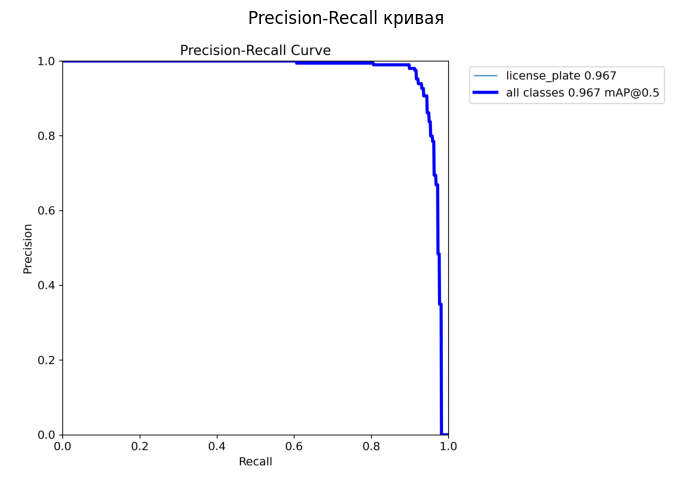

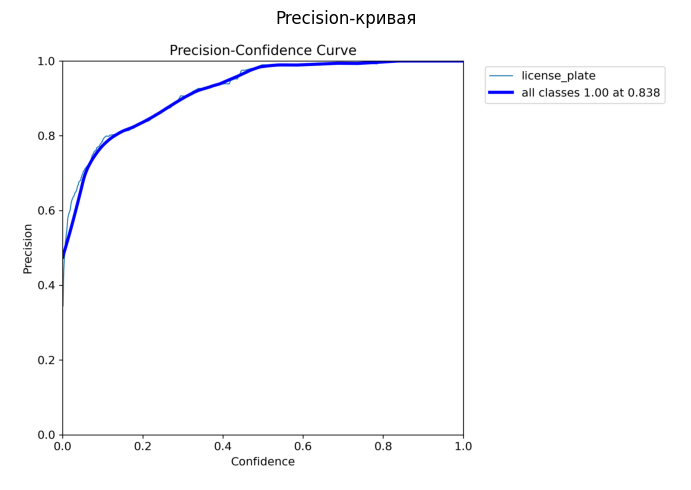

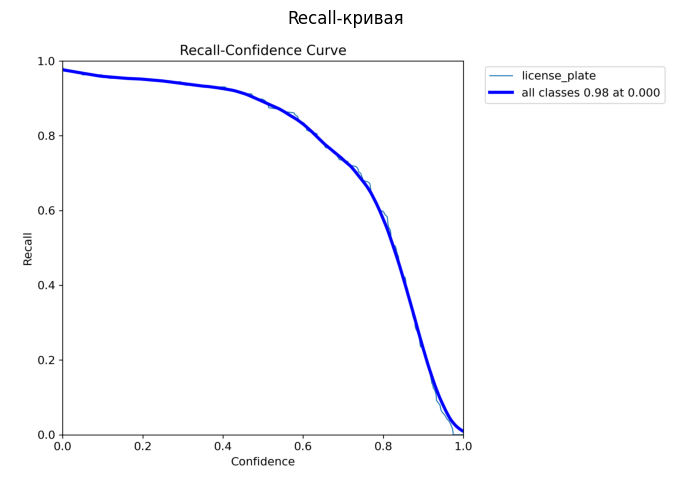

In [13]:
import matplotlib.image as _mpimg

_save_dir = Path(plate_model.trainer.save_dir)
print(f'Папка с результатами обучения: {_save_dir}')

_SHOW_PLOTS = {
    'BoxF1_curve.png': 'F1-кривая по порогу уверенности',
    'BoxPR_curve.png': 'Precision-Recall кривая',
    'BoxP_curve.png': 'Precision-кривая',
    'BoxR_curve.png': 'Recall-кривая',
}

for _fname, _title in _SHOW_PLOTS.items():
    _p = _save_dir / _fname
    if not _p.exists():
        print(f'Файл не найден: {_fname}')
        continue
    _img = _mpimg.imread(str(_p))
    plt.figure(figsize=(13, 5))
    plt.imshow(_img)
    plt.title(_title, fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [14]:
plate_eval = YOLO(str(PLATES_MODEL_PATH))
metrics = plate_eval.val(data=DATA_YAML, device=DEVICE, verbose=False)
map50 = metrics.box.map50
map5095 = metrics.box.map
print(f'mAP@0.5:      {map50:.4f}')
print(f'mAP@0.5:0.95: {map5095:.4f}')

with open(OUTPUT_DIR / 'detection_metrics.json', 'w') as f:
    json.dump({'map50': round(map50, 4), 'map5095': round(map5095, 4)}, f, indent=2)
print(f'Метрики → {OUTPUT_DIR}/detection_metrics.json')

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3151.2±888.5 MB/s, size: 139.0 KB)
val: Scanning /content/diploma_01_detection/data/plates/raw/test/labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 44.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5it/s 3.3s
                   all        126        216      0.977      0.912      0.967       0.59
Speed: 2.8ms preprocess, 6.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5:      0.9669
mAP@0.5:0.95: 0.5902
Метрики → diploma_01_detection/output/detection_metrics.json


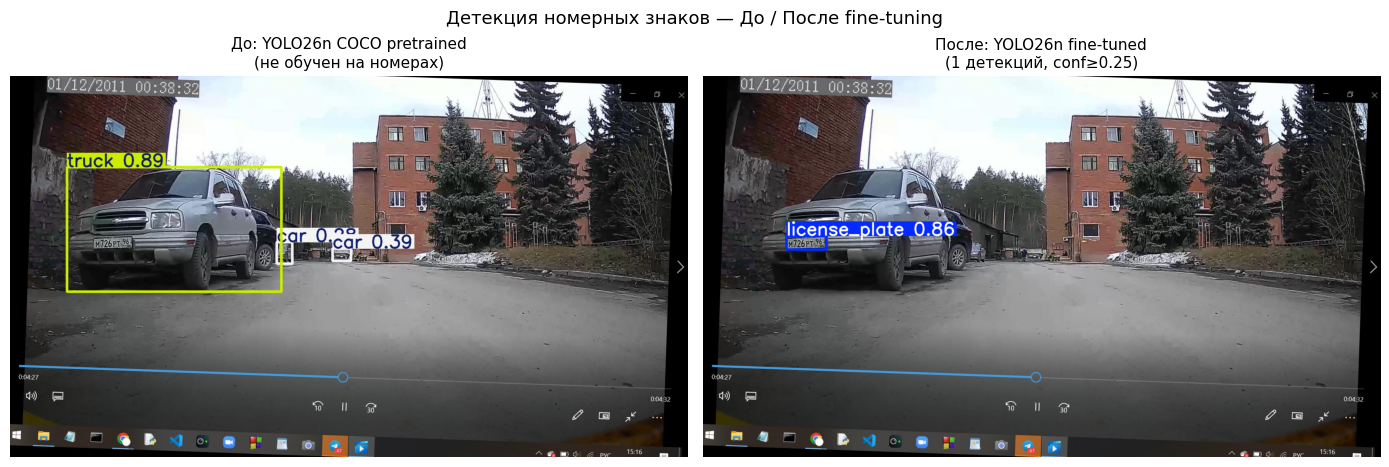

In [15]:
_test_dir = RAW_DIR / 'test' / 'images'
_test_imgs = sorted(list(_test_dir.glob('*.jpg')) + list(_test_dir.glob('*.png')))
_sample_bgr = cv2.imread(str(_test_imgs[0]))

_plate_eval_model = YOLO(str(PLATES_MODEL_PATH))

_res_before = vehicle_model(_sample_bgr, conf=0.25, verbose=False)[0]
_ann_before = _res_before.plot()

_res_after = _plate_eval_model(_sample_bgr, conf=0.25, verbose=False)[0]
_ann_after = _res_after.plot()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(_ann_before, cv2.COLOR_BGR2RGB))
axes[0].set_title('До: YOLO26n COCO pretrained\n(не обучен на номерах)', fontsize=11)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(_ann_after, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f'После: YOLO26n fine-tuned\n({len(_res_after.boxes)} детекций, conf≥0.25)', fontsize=11)
axes[1].axis('off')
plt.suptitle('Детекция номерных знаков — До / После fine-tuning', fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'before_after_finetuning.png'), dpi=130, bbox_inches='tight')
plt.show()

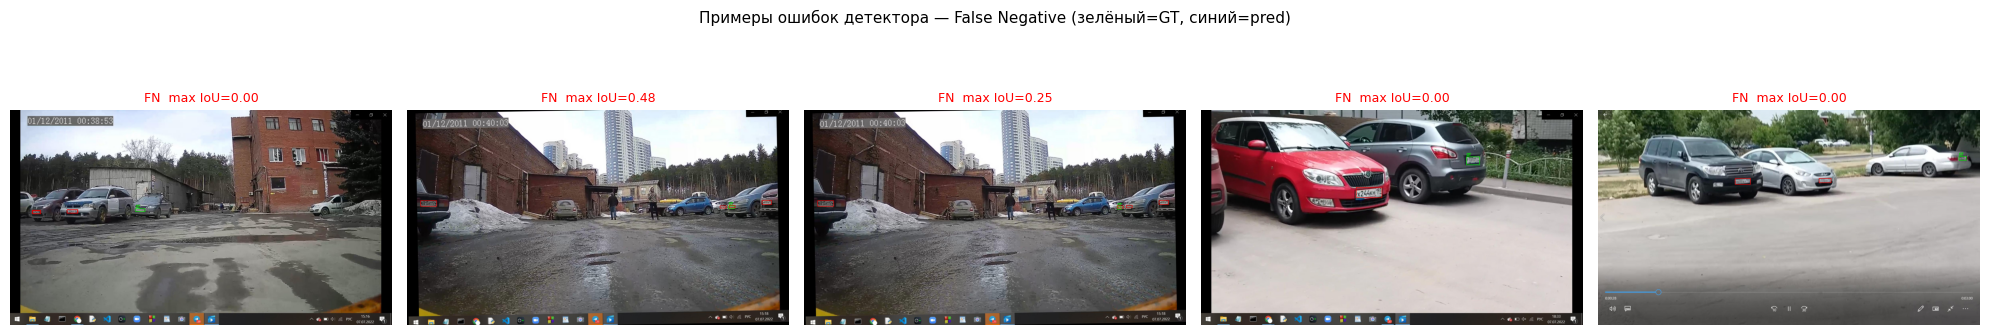

Показано 5 False Negative примеров


In [16]:
def _gt_boxes_from_label(lbl_path, img_w, img_h):
    """Читает YOLO-формат .txt → список [x1, y1, x2, y2] в пикселях."""
    boxes = []
    if not Path(lbl_path).exists():
        return boxes
    for line in Path(lbl_path).read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = int((cx - w / 2) * img_w)
        y1 = int((cy - h / 2) * img_h)
        x2 = int((cx + w / 2) * img_w)
        y2 = int((cy + h / 2) * img_h)
        boxes.append([x1, y1, x2, y2])
    return boxes


def _iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    ua = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / ua if ua > 0 else 0.0


_test_dir = RAW_DIR / 'test' / 'images'
_test_imgs = sorted(list(_test_dir.glob('*.jpg')) + list(_test_dir.glob('*.png')))
_test_lbls = RAW_DIR / 'test' / 'labels'
_fn_examples = []
for _img_p in _test_imgs[:80]:
    _lbl_p = _test_lbls / (_img_p.stem + '.txt')
    _bgr = cv2.imread(str(_img_p))
    if _bgr is None:
        continue
    H, W = _bgr.shape[:2]
    _gt = _gt_boxes_from_label(_lbl_p, W, H)
    if not _gt:
        continue
    _preds = _plate_eval_model(_bgr, conf=0.3, verbose=False)[0].boxes
    _pred_boxes = [list(map(int, b.xyxy[0].cpu().numpy())) for b in _preds] if _preds else []
    for _gt_box in _gt:
        max_iou = max((_iou(_gt_box, pb) for pb in _pred_boxes), default=0.0)
        if max_iou < 0.5:
            _fn_examples.append((_bgr.copy(), _gt_box, _pred_boxes, max_iou))
    if len(_fn_examples) >= 6:
        break

if not _fn_examples:
    print('False Negative не найдено в первых 80 кадрах — модель работает хорошо!')
else:
    n = len(_fn_examples)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (_bgr_ex, _gt_b, _pred_bs, _max_iou) in zip(axes, _fn_examples):
        _vis = _bgr_ex.copy()
        cv2.rectangle(_vis, (_gt_b[0], _gt_b[1]), (_gt_b[2], _gt_b[3]), (0, 220, 0), 2)
        cv2.putText(_vis, 'GT', (_gt_b[0], _gt_b[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 220, 0), 2)
        for _pb in _pred_bs:
            cv2.rectangle(_vis, (_pb[0], _pb[1]), (_pb[2], _pb[3]), (0, 0, 220), 2)
        ax.imshow(cv2.cvtColor(_vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f'FN  max IoU={_max_iou:.2f}', fontsize=9, color='red')
        ax.axis('off')
    plt.suptitle('Примеры ошибок детектора — False Negative (зелёный=GT, синий=pred)', fontsize=11)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'detection_errors_fn.png'), dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Показано {n} False Negative примеров')

## 4. OCR номерных знаков — EasyOCR

Формат российского номера: `[АВЕКМНОРСТУХ]\d{3}[АВЕКМНОРСТУХ]{2}\d{2,3}`

In [17]:
import easyocr

reader = easyocr.Reader(['ru', 'en'], gpu=(DEVICE == 'cuda'), verbose=False)
print('EasyOCR загружен.')

_PLATE_LETTERS = 'АВЕКМНОРСТУХ'
_PLATE_ALLOWLIST = 'АВЕКМНОРСТУХABEKMHOPCTYX0123456789'

_LAT_TO_RUS = str.maketrans({
    'A': 'А', 'B': 'В', 'E': 'Е', 'K': 'К', 'M': 'М', 'H': 'Н',
    'O': 'О', 'P': 'Р', 'C': 'С', 'T': 'Т', 'X': 'Х', 'Y': 'У',
})
_RU_RE = re.compile(rf'[{_PLATE_LETTERS}]\d{{3}}[{_PLATE_LETTERS}]{{2}}\d{{2,3}}')

_DIGIT_POSITIONS = {1, 2, 3, 6, 7, 8}

_DIGIT_FROM_LETTER = {'З': '3', 'О': '0', 'Д': '0', 'Б': '6', 'Г': '7', 'Т': '7'}


def _preprocess_plate(bgr: np.ndarray) -> np.ndarray:
    """Апскейл + умная бинаризация: Otsu с fallback на адаптивную пороговую обработку."""
    h, w = bgr.shape[:2]
    scale = max(300.0 / max(w, 1), 50.0 / max(h, 1), 1.0)
    if scale > 1.0:
        bgr = cv2.resize(bgr, (int(w * scale), int(h * scale)),
                         interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if 0.10 < (otsu == 255).mean() < 0.90:
        return otsu

    return cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10
    )


def _position_correct(text: str) -> str:
    """Корректировка символов по позиции: на цифровых позициях З→3, О→0 и т.д."""
    if len(text) not in (8, 9):
        return text
    chars = list(text)
    for pos in _DIGIT_POSITIONS:
        if pos < len(chars) and not chars[pos].isdigit():
            chars[pos] = _DIGIT_FROM_LETTER.get(chars[pos], chars[pos])
    return ''.join(chars)


def ocr_plate(plate_bgr: np.ndarray) -> dict:
    """OCR номерного знака с предобработкой и позиционной коррекцией.
    Drop-in замена: та же сигнатура и схема возврата.
    """
    if plate_bgr is None or plate_bgr.size == 0:
        return {'text': '', 'confidence': 0.0, 'valid': False}

    processed = _preprocess_plate(plate_bgr)

    res = reader.readtext(processed, detail=1, allowlist=_PLATE_ALLOWLIST,
                          paragraph=False, batch_size=1, workers=0)
    if not res:
        return {'text': '', 'confidence': 0.0, 'valid': False}

    res.sort(key=lambda r: (r[0][0][0] + r[0][2][0]) / 2)

    raw = ''.join(t for (_, t, _c) in res)
    text = raw.upper().replace(' ', '').replace('-', '').translate(_LAT_TO_RUS)

    text = _position_correct(text)

    m = _RU_RE.search(text)
    plate_text = m.group(0) if m else text[:9]
    conf = sum(c for (_, _, c) in res) / max(len(res), 1)

    return {'text': plate_text, 'confidence': round(conf, 3), 'valid': m is not None}


def cer(ref: str, hyp: str) -> float:
    """Character Error Rate через расстояние Левенштейна (доля ошибочных символов)."""
    if not ref:
        return 0.0 if not hyp else 1.0
    d = np.zeros((len(ref) + 1, len(hyp) + 1), dtype=int)
    for i in range(len(ref) + 1):
        d[i][0] = i
    for j in range(len(hyp) + 1):
        d[0][j] = j
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            d[i][j] = min(d[i - 1][j] + 1, d[i][j - 1] + 1, d[i - 1][j - 1] + cost)
    return d[len(ref)][len(hyp)] / len(ref)

EasyOCR загружен.


### OCR на реальных данных — NOMEROFF-NET RU

Для количественной оценки OCR на реальных российских номерных знаках
используется датасет **AUTO.RIA Numberplate OCR RU** (NOMEROFF-NET, CC BY).
Он содержит обрезанные изображения номеров с текстовой разметкой в JSON-аннотациях.

Оценка проводится на **200 случайных** изображениях из test-split (seed=42).
Метрики: **Plate Accuracy** (точное совпадение) и **CRR** (1 − CER).

In [18]:
import json as _json_nn
import random as _random_nn
import cv2 as _cv2_nn

_NN_DIR = DATA_DIR / 'nomeroff_ru'
_NN_ZIP = DATA_DIR / 'nomeroff_ru.zip'
_NN_URL = 'https://nomeroff.net.ua/datasets/autoriaNumberplateOcrRu-2021-09-01.zip'

if not _NN_DIR.exists() or not list(_NN_DIR.rglob('*.jpg')):
    print('Скачиваем NOMEROFF-NET RU (~1.5 ГБ)...')
    _nn_zip_s, _nn_dir_s = str(_NN_ZIP), str(_NN_DIR)
    !wget -q --show-progress "$_NN_URL" -O "$_nn_zip_s"
    !unzip -q "$_nn_zip_s" -d "$_nn_dir_s"
    _NN_ZIP.unlink(missing_ok=True)
    print('Датасет извлечён.')
else:
    print('NOMEROFF-NET RU уже скачан.')

_img_roots = sorted(_NN_DIR.rglob('img'))
_ann_roots = sorted(_NN_DIR.rglob('ann'))
_img_root, _ann_root = _img_roots[0], _ann_roots[0]

for _split in ('test', 'val', ''):
    _img_dir = _img_root / _split if _split else _img_root
    _ann_dir = _ann_root / _split if _split else _ann_root
    if _img_dir.exists():
        break
print(f'Split: {_split or "all"}')

_pairs = []
for _ext in ('*.jpg', '*.png', '*.jpeg'):
    for _img_p in sorted(_img_dir.glob(_ext)):
        _ann_p = _ann_dir / (_img_p.stem + '.json')
        if not _ann_p.exists():
            continue
        try:
            with open(_ann_p) as _f:
                _d = _json_nn.load(_f)
            _gt = _d.get('description', '').strip().upper()
            _gt = _gt.replace(' ', '').replace('-', '').translate(_LAT_TO_RUS)
            if _gt:
                _pairs.append((_img_p, _gt))
        except Exception:
            continue

print(f'Пар image-GT: {len(_pairs)}')

_random_nn.seed(42)
_sample_nn = _random_nn.sample(_pairs, min(200, len(_pairs)))

_nn_results = []
for _img_p, _gt in _sample_nn:
    _img = _cv2_nn.imread(str(_img_p))
    if _img is None:
        continue
    _pred = ocr_plate(_img)
    _c = cer(_gt, _pred['text'])
    _nn_results.append({'reference': _gt, 'recognized': _pred['text'],
                        'cer': round(_c, 4)})

nomeroff_plate_acc = sum(r['reference'] == r['recognized'] for r in _nn_results) / len(_nn_results)
nomeroff_crr = 1.0 - float(np.mean([r['cer'] for r in _nn_results]))
print(f'\nNOMEROFF-NET RU ({len(_nn_results)} изображений):')
print(f'  Plate Accuracy : {nomeroff_plate_acc:.4f}')
print(f'  CRR            : {nomeroff_crr:.4f}')

with open(OUTPUT_DIR / 'ocr_nomeroff_metrics.json', 'w', encoding='utf-8') as _f:
    _json_nn.dump({'dataset': 'autoriaNumberplateOcrRu-2021-09-01',
                   'split': _split or 'all', 'n_samples': len(_nn_results),
                   'plate_accuracy': round(nomeroff_plate_acc, 4),
                   'crr': round(nomeroff_crr, 4)},
                  _f, ensure_ascii=False, indent=2)

Скачиваем NOMEROFF-NET RU (~1.5 ГБ)...
diploma_01_detectio 100%[===================>]   1.40G  16.7MB/s    in 87s     
Датасет извлечён.
Split: all
Пар image-GT: 2845

NOMEROFF-NET RU (200 изображений):
  Plate Accuracy : 0.2250
  CRR            : 0.7503


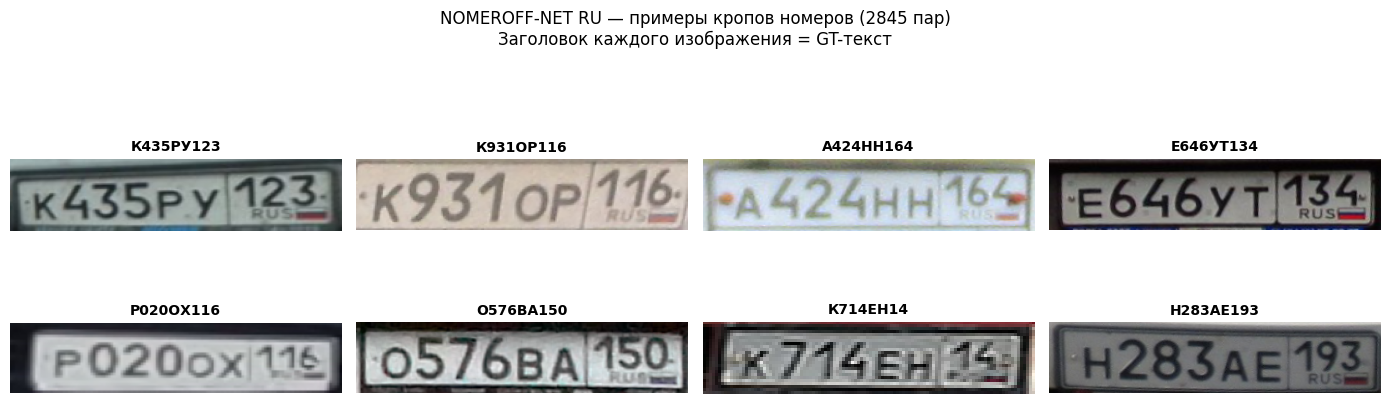

In [19]:
import random as _rnd_nn_prev

_rnd_nn_prev.seed(0)
_nn_prev = _rnd_nn_prev.sample(_pairs, min(8, len(_pairs)))

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, (_img_p, _gt) in zip(axes.flat, _nn_prev):
    _bgr = cv2.imread(str(_img_p))
    ax.imshow(cv2.cvtColor(_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(_gt, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle(
    f'NOMEROFF-NET RU — примеры кропов номеров ({len(_pairs)} пар)\n'
    f'Заголовок каждого изображения = GT-текст',
    fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'dataset_nomeroff_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

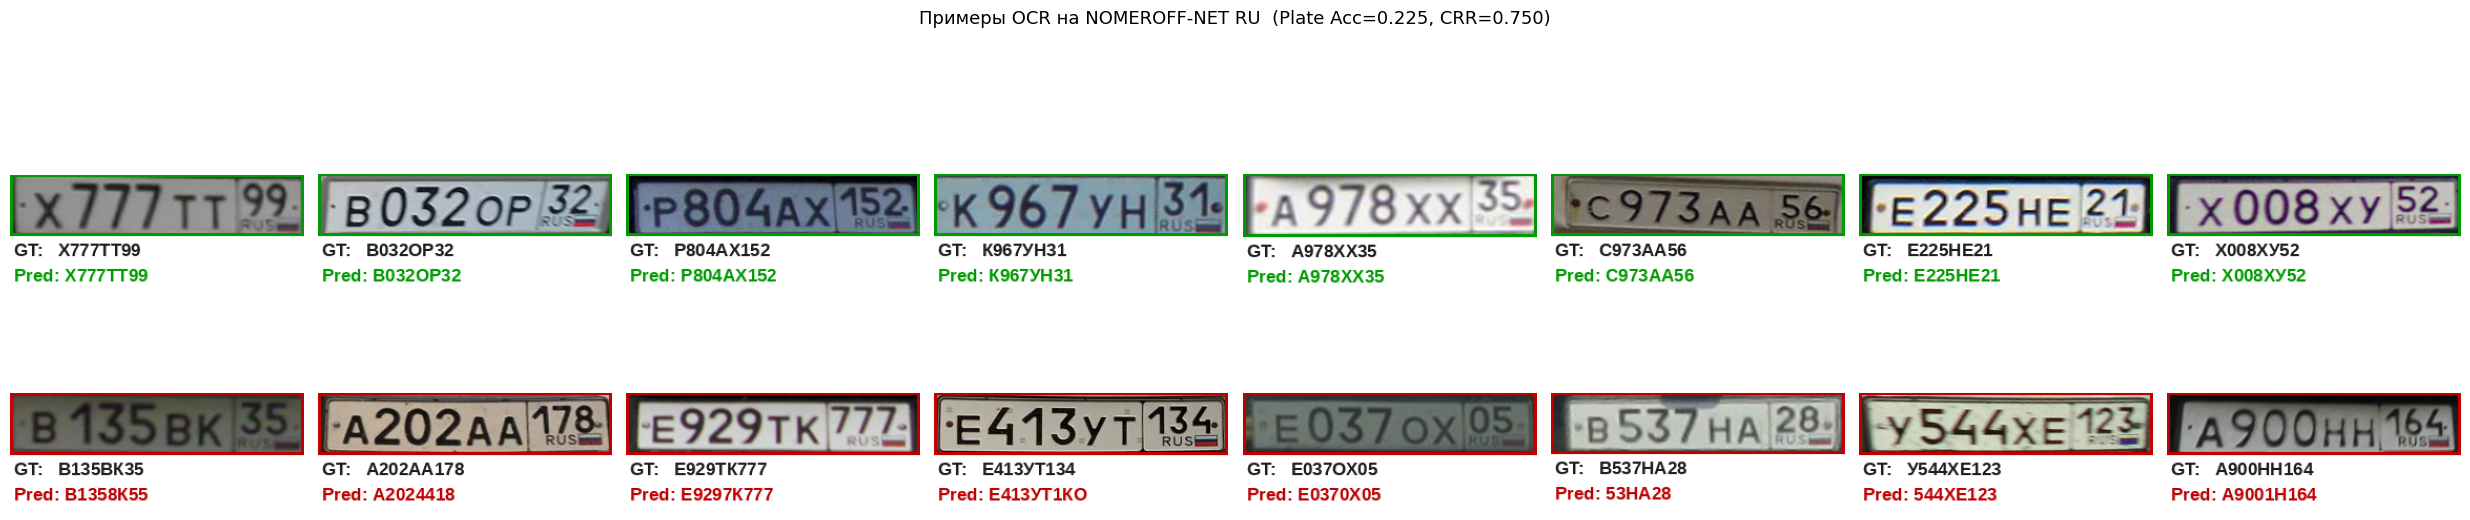

Верных примеров показано:  8
Ошибочных примеров показано: 8


In [20]:
from PIL import Image as _PILv, ImageDraw as _DRWv, ImageFont as _FNTv

_vis_font_lg, _vis_font_sm = None, None
for _fp in ['/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf']:
    try:
        _vis_font_lg = _FNTv.truetype(_fp, 17)
        _vis_font_sm = _FNTv.truetype(_fp, 13)
        break
    except OSError:
        pass
if _vis_font_lg is None:
    _vis_font_lg = _vis_font_sm = _FNTv.load_default()


_vis_correct, _vis_wrong = [], []
for _img_p, _gt in _sample_nn:
    if len(_vis_correct) >= 8 and len(_vis_wrong) >= 8:
        break
    _img = cv2.imread(str(_img_p))
    if _img is None:
        continue
    _pred = ocr_plate(_img)
    _entry = {'img_bgr': _img, 'gt': _gt, 'pred': _pred['text'],
              'conf': _pred['confidence']}
    if _pred['text'] == _gt and len(_vis_correct) < 8:
        _vis_correct.append(_entry)
    elif _pred['text'] != _gt and len(_vis_wrong) < 8:
        _vis_wrong.append(_entry)


def _draw_plate_card(bgr, gt, pred, correct):
    """Масштабирует кроп до 280px, добавляет рамку и подписи GT/Pred."""
    W = 280
    h, w = bgr.shape[:2]
    scaled = cv2.resize(bgr, (W, max(int(h * W / max(w, 1)), 36)),
                        interpolation=cv2.INTER_CUBIC)
    pad = 52
    canvas = np.full((scaled.shape[0] + pad, W, 3), 255, dtype=np.uint8)
    canvas[:scaled.shape[0]] = scaled

    img_pil = _PILv.fromarray(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    draw = _DRWv.Draw(img_pil)
    color = (0, 155, 0) if correct else (190, 0, 0)
    draw.rectangle([(0, 0), (W - 1, scaled.shape[0] - 1)], outline=color, width=3)

    y0 = scaled.shape[0] + 3
    draw.text((4, y0),      f'GT:   {gt}',   fill=(30, 30, 30),  font=_vis_font_lg)
    draw.text((4, y0 + 24), f'Pred: {pred}', fill=color,         font=_vis_font_lg)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)


_N = min(8, len(_vis_correct), len(_vis_wrong))
assert _N > 0, 'Нет примеров для визуализации — перезапустите ячейку выше'

fig, axes = plt.subplots(2, _N, figsize=(_N * 3.1, 6.2))
if _N == 1:
    axes = [[axes[0]], [axes[1]]]

for col, entry in enumerate(_vis_correct[:_N]):
    card = _draw_plate_card(entry['img_bgr'], entry['gt'], entry['pred'], True)
    axes[0][col].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[0][col].axis('off')

for col, entry in enumerate(_vis_wrong[:_N]):
    card = _draw_plate_card(entry['img_bgr'], entry['gt'], entry['pred'], False)
    axes[1][col].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[1][col].axis('off')

plt.suptitle(
    f'Примеры OCR на NOMEROFF-NET RU  '
    f'(Plate Acc={nomeroff_plate_acc:.3f}, CRR={nomeroff_crr:.3f})',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'nomeroff_ocr_examples.png'), dpi=130, bbox_inches='tight')
plt.show()
print(f'Верных примеров показано:  {len(_vis_correct[:_N])}')
print(f'Ошибочных примеров показано: {len(_vis_wrong[:_N])}')

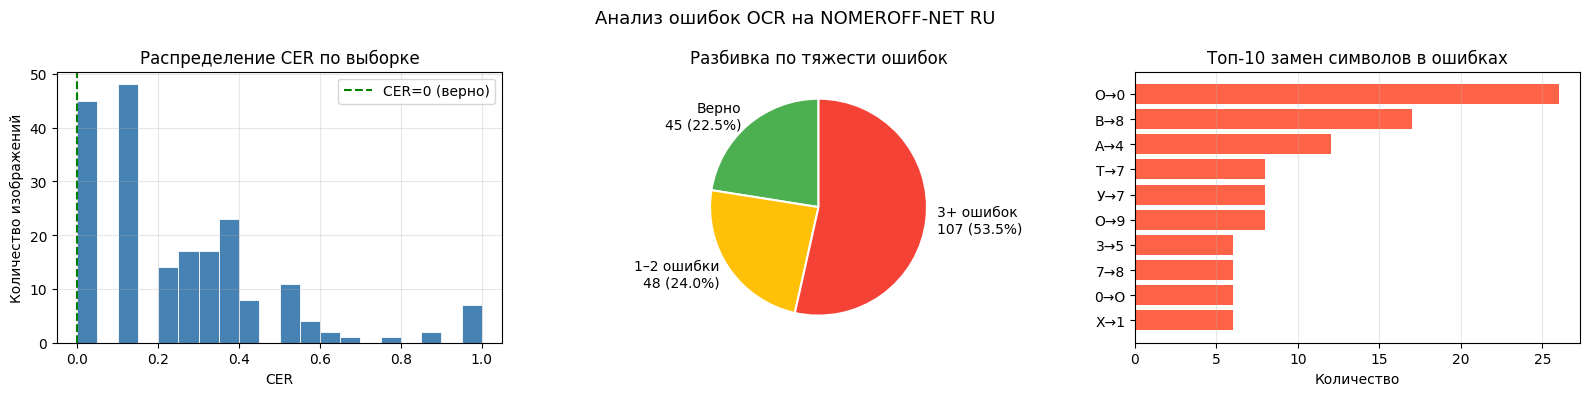

Топ замен символов:
  GT    → Pred   Кол-во
  ──────────────────────
  'О'   → '0'    26
  'В'   → '8'    17
  'А'   → '4'    12
  'Т'   → '7'    8
  'У'   → '7'    8
  'О'   → '9'    8
  '3'   → '5'    6
  '7'   → '8'    6


In [21]:
import pandas as pd
from collections import Counter

_cers = [r['cer'] for r in _nn_results]
_correct_mask = [r['reference'] == r['recognized'] for r in _nn_results]

def _char_substitutions(ref, hyp):
    """Простой выравниватель: возвращает список (ref_char, hyp_char) замен."""
    subs = []
    for r_c, h_c in zip(ref, hyp):
        if r_c != h_c:
            subs.append((r_c, h_c))
    return subs

_sub_counter = Counter()
for r in _nn_results:
    if r['reference'] != r['recognized']:
        _sub_counter.update(_char_substitutions(r['reference'], r['recognized']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Гистограмма CER
axes[0].hist(_cers, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].axvline(0, color='green', linestyle='--', linewidth=1.5, label='CER=0 (верно)')
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Количество изображений')
axes[0].set_title('Распределение CER по выборке')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Пирог: верно / 1 ошибка / 2+ ошибок
_n_correct = sum(_correct_mask)
_n_one_err = sum(1 for c in _cers if 0 < c <= 0.15)
_n_many    = sum(1 for c in _cers if c > 0.15)
_pie_vals  = [_n_correct, _n_one_err, _n_many]
_pie_lbls  = [
    f'Верно\n{_n_correct} ({_n_correct / len(_cers) * 100:.1f}%)',
    f'1–2 ошибки\n{_n_one_err} ({_n_one_err / len(_cers) * 100:.1f}%)',
    f'3+ ошибок\n{_n_many} ({_n_many / len(_cers) * 100:.1f}%)',
]
axes[1].pie(_pie_vals, labels=_pie_lbls, colors=['#4CAF50', '#FFC107', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Разбивка по тяжести ошибок')

# 3. Топ-10 типичных замен символов
_top_subs = _sub_counter.most_common(10)
if _top_subs:
    _sub_labels = [f'{r}→{h}' for (r, h), _ in _top_subs]
    _sub_counts = [cnt for _, cnt in _top_subs]
    axes[2].barh(_sub_labels[::-1], _sub_counts[::-1], color='tomato')
    axes[2].set_xlabel('Количество')
    axes[2].set_title('Топ-10 замен символов в ошибках')
    axes[2].grid(axis='x', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'Нет ошибок для анализа', ha='center', va='center',
                 transform=axes[2].transAxes)
    axes[2].set_title('Топ замен символов')

plt.suptitle('Анализ ошибок OCR на NOMEROFF-NET RU', fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'nomeroff_ocr_error_analysis.png'), dpi=130, bbox_inches='tight')
plt.show()

# ── Топ-5 замен в таблице ─────────────────────────────────────────────────────
if _top_subs:
    print('Топ замен символов:')
    print(f'  {"GT":5s} → {"Pred":5s}  Кол-во')
    print('  ' + '─' * 22)
    for (r, h), cnt in _top_subs[:8]:
        print(f'  {repr(r):5s} → {repr(h):5s}  {cnt}')

In [22]:
from google.colab import files
import zipfile
import pandas as pd

det = {}
det_json = OUTPUT_DIR / 'detection_metrics.json'
if det_json.exists():
    with open(det_json) as f:
        det = json.load(f)

table = pd.DataFrame({
    'Модуль': [
        'Детекция ТС (YOLO26n COCO)',
        'Детекция номеров (YOLO26n)',
        'OCR (EasyOCR, NOMEROFF-NET RU)',
    ],
    'Метрика': [
        'mAP@0.5 (pretrained)',
        'mAP@0.5 (fine-tuned)',
        'Plate Acc / CRR',
    ],
    'Значение': [
        '~0.503 (COCO val)',
        str(det.get('map50', 'обучите детектор выше')),
        f'{nomeroff_plate_acc:.3f} / {nomeroff_crr:.3f}',
    ],
})
print('\u2500' * 62)
print(table.to_string(index=False))
print('\u2500' * 62)

with zipfile.ZipFile('results_01_detection.zip', 'w') as zf:
    for p in OUTPUT_DIR.glob('*'):
        zf.write(p, p.name)
files.download('results_01_detection.zip')

──────────────────────────────────────────────────────────────
                        Модуль              Метрика          Значение
    Детекция ТС (YOLO26n COCO) mAP@0.5 (pretrained) ~0.503 (COCO val)
    Детекция номеров (YOLO26n) mAP@0.5 (fine-tuned)            0.9669
OCR (EasyOCR, NOMEROFF-NET RU)      Plate Acc / CRR     0.225 / 0.750
──────────────────────────────────────────────────────────────


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Сравнение с базовой моделью YOLOv8n

Основная модель YOLO26n уже дообучена выше (секция 3). Здесь для сравнения
дообучаем baseline-модель предыдущего поколения YOLOv8n на том же датасете
с теми же гиперпараметрами, затем сравниваем обе fine-tuned модели по метрикам
(mAP@0.5, mAP@0.5:0.95, precision, recall, inference time) и автоматически
выбираем лучшую — сохраняем выбор в `detector_choice.json` для использования в
финальном конвейере (ноутбук 04).

In [23]:
import shutil

plate_model_v8 = YOLO('yolov8n.pt')
plate_model_v8.train(
    data=DATA_YAML,
    epochs=50,
    batch=16,
    imgsz=640,
    device=DEVICE,
    project=str(WORK_DIR / 'runs'),
    name='plates_yolov8n',
    patience=15,
    val=True,
)
_best_v8 = Path(plate_model_v8.trainer.best)
shutil.copy(_best_v8, YOLOV8_PLATES_MODEL_PATH)
plate_model_v8 = YOLO(str(YOLOV8_PLATES_MODEL_PATH))
print(f'Веса YOLOv8n (baseline) → {YOLOV8_PLATES_MODEL_PATH}')

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=diploma_01_detection/data/plates/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plates_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2947.5±1052.7 MB/s, size: 139.0 KB)
val: Scanning /content/diploma_01_detection/data/plates/raw/test/labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 52.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 4.0s
                   all        126        216      0.977      0.926      0.955      0.593
Speed: 4.6ms preprocess, 4.8ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val-2
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2996.3±903.2 MB/s, size: 161.8 KB)


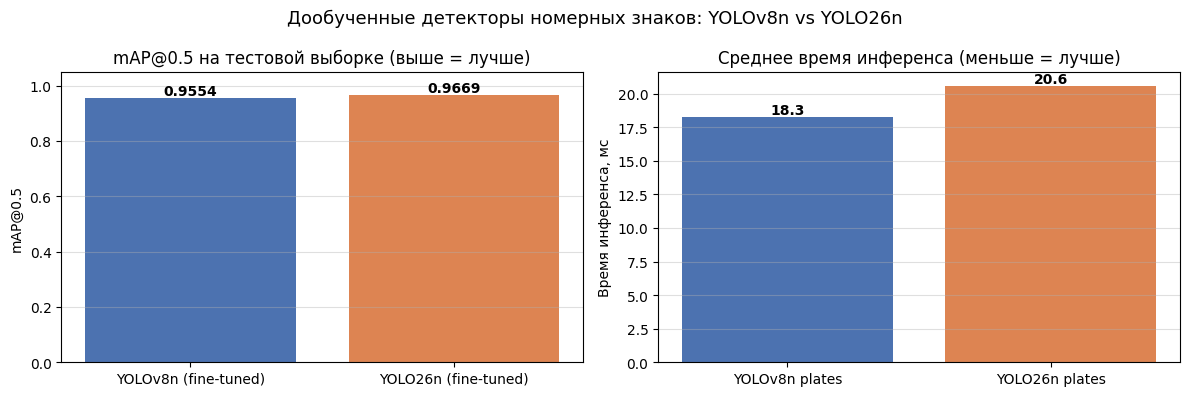

In [24]:
import time
import pandas as pd

_v8_eval = YOLO(str(YOLOV8_PLATES_MODEL_PATH))
_v26_eval = YOLO(str(PLATES_MODEL_PATH))

_metrics_v8 = _v8_eval.val(data=DATA_YAML, device=DEVICE, verbose=False)
_metrics_v26 = _v26_eval.val(data=DATA_YAML, device=DEVICE, verbose=False)

_rows = []
for _lbl, _met in [('YOLOv8n (fine-tuned)', _metrics_v8),
                   ('YOLO26n (fine-tuned)', _metrics_v26)]:
    _rows.append({
        'Модель': _lbl,
        'mAP@0.5': round(_met.box.map50, 4),
        'mAP@0.5:0.95': round(_met.box.map, 4),
        'Precision': round(_met.box.mp, 4),
        'Recall': round(_met.box.mr, 4),
    })

_df_cmp = pd.DataFrame(_rows)
print('── Метрики дообученных детекторов номеров ──')
print(_df_cmp.to_string(index=False))

_test_imgs = sorted(
    list((RAW_DIR / 'test' / 'images').glob('*.jpg')) +
    list((RAW_DIR / 'test' / 'images').glob('*.png'))
)[:10]

if not _test_imgs:
    print('\nПредупреждение: тестовые изображения не найдены, пропускаем замер скорости.')
    _df_sp = pd.DataFrame([{'Модель': 'YOLOv8n plates', 'Среднее время, мс': 'н/д'},
                           {'Модель': 'YOLO26n plates', 'Среднее время, мс': 'н/д'}])
else:
    _sp_rows = []
    for _lbl, _mp in [('YOLOv8n plates', YOLOV8_PLATES_MODEL_PATH),
                      ('YOLO26n plates', PLATES_MODEL_PATH)]:
        _mdl = YOLO(str(_mp))
        _mdl(cv2.imread(str(_test_imgs[0])), verbose=False)  # warm-up
        _t0 = time.perf_counter()
        for _ip in _test_imgs:
            _mdl(cv2.imread(str(_ip)), conf=0.4, verbose=False)
        _ms = (time.perf_counter() - _t0) / len(_test_imgs) * 1000
        _sp_rows.append({'Модель': _lbl, 'Среднее время, мс': round(_ms, 1)})
    _df_sp = pd.DataFrame(_sp_rows)
    print('\n── Скорость инференса ──')
    print(_df_sp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0', '#DD8452']

axes[0].bar(_df_cmp['Модель'], _df_cmp['mAP@0.5'], color=colors)
axes[0].set_ylabel('mAP@0.5')
axes[0].set_title('mAP@0.5 на тестовой выборке (выше = лучше)')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.4)
for i, v in enumerate(_df_cmp['mAP@0.5']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

if _test_imgs:
    axes[1].bar(_df_sp['Модель'], _df_sp['Среднее время, мс'], color=colors)
    axes[1].set_ylabel('Время инференса, мс')
    axes[1].set_title('Среднее время инференса (меньше = лучше)')
    axes[1].grid(axis='y', alpha=0.4)
    for i, v in enumerate(_df_sp['Среднее время, мс']):
        axes[1].text(i, v + 0.2, f'{v}', ha='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Нет тестовых изображений', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=11, color='gray')
    axes[1].set_title('Среднее время инференса')

plt.suptitle('Дообученные детекторы номерных знаков: YOLOv8n vs YOLO26n', fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'finetuned_plates_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()

In [25]:
_map50_v8 = _metrics_v8.box.map50
_map50_v26 = _metrics_v26.box.map50

if _map50_v26 >= _map50_v8:
    _winner = 'YOLO26n'
    _vehicle_model = 'yolo26n.pt'
    _plates_model = str(PLATES_MODEL_PATH)
else:
    _winner = 'YOLOv8n'
    _vehicle_model = 'yolov8n.pt'
    _plates_model = str(YOLOV8_PLATES_MODEL_PATH)

_choice = {
    'winner': _winner,
    'vehicle_model': _vehicle_model,
    'plates_model': _plates_model,
    'metrics': {
        'YOLOv8n': {
            'mAP50': round(_map50_v8, 4),
            'mAP5095': round(_metrics_v8.box.map, 4),
        },
        'YOLO26n': {
            'mAP50': round(_map50_v26, 4),
            'mAP5095': round(_metrics_v26.box.map, 4),
        },
    }
}

_choice_path = DRIVE_MODELS / 'detector_choice.json'
with open(_choice_path, 'w', encoding='utf-8') as _f:
    json.dump(_choice, _f, indent=2, ensure_ascii=False)

print('=' * 55)
print(f'  Победитель: {_winner}')
print(f'  mAP@0.5  — YOLOv8n: {_map50_v8:.4f}  YOLO26n: {_map50_v26:.4f}')
print(f'  vehicle_model : {_vehicle_model}')
print(f'  plates_model  : {_plates_model}')
print(f'  Сохранено: {_choice_path}')
print('=' * 55)
print('Модель-победитель будет автоматически загружена в notebook 04.')

  Победитель: YOLO26n
  mAP@0.5  — YOLOv8n: 0.9554  YOLO26n: 0.9669
  vehicle_model : yolo26n.pt
  plates_model  : /content/drive/MyDrive/diploma/models/yolo26n_plates.pt
  Сохранено: /content/drive/MyDrive/diploma/models/detector_choice.json
Модель-победитель будет автоматически загружена в notebook 04.
